<a href="https://colab.research.google.com/github/Piyush-Sharma-1/SI_Crystal_Generative_Model/blob/main/LJ_cluster_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ase -q
!pip install torch-geometric -q

[v4i3] using source at: /kaggle/input/datasets/phantomygyj/atomic-recipes/atomic-recipes-code/atomic-recipes-main
[v4i3] confirmed EquivariantDecoder present
device: cuda
ep  1 | kl_w 0.0001 | kl 12.28 | agg 152.4 | SCORE 0.9834 | total 153.4
ep  2 | kl_w 0.0501 | kl 14.2 | agg 134.9 | SCORE 0.9332 | total 136.5
ep  3 | kl_w 0.1001 | kl 19.85 | agg 120.5 | SCORE 0.804 | total 123.3
ep  4 | kl_w 0.1501 | kl 30.1 | agg 100.9 | SCORE 0.9092 | total 106.3
ep  5 | kl_w 0.2001 | kl 45.5 | agg 84.14 | SCORE 0.9397 | total 94.19
ep  6 | kl_w 0.2501 | kl 66.53 | agg 69.06 | SCORE 0.9494 | total 86.64
ep  7 | kl_w 0.3001 | kl 92.09 | agg 48.15 | SCORE 0.849 | total 76.63
ep  8 | kl_w 0.3501 | kl 112.8 | agg 38.59 | SCORE 0.9076 | total 78.98
ep  9 | kl_w 0.4001 | kl 114.9 | agg 30.84 | SCORE 0.9726 | total 77.79
ep 10 | kl_w 0.4501 | kl 100 | agg 28.88 | SCORE 0.9757 | total 74.86
ep 11 | kl_w 0.5000 | kl 79.49 | agg 31.65 | SCORE 0.9337 | total 72.33
ep 12 | kl_w 0.5500 | kl 63.13 | agg 35.8 | 

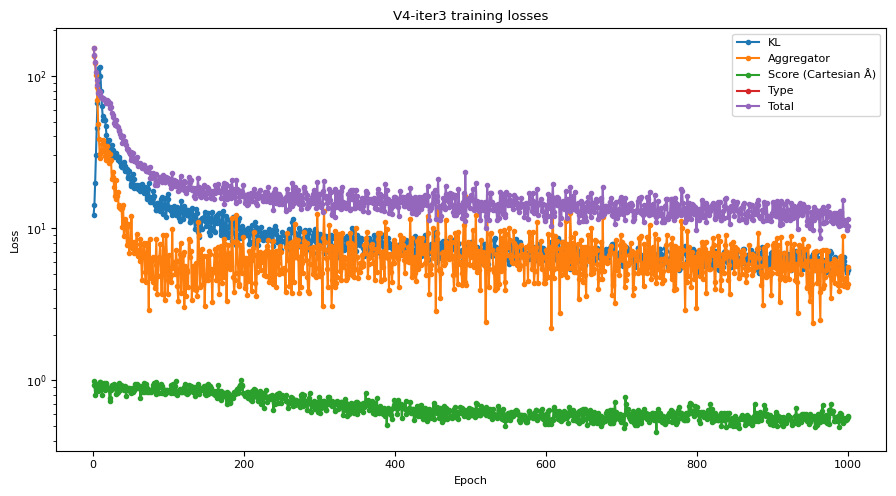

In [ ]:
#training script:

import sys, os, json, time, glob, itertools, importlib
from pathlib import Path

V4_ROOT = "/kaggle/input/datasets/phantomygyj/atomic-recipes/atomic-recipes-code/atomic-recipes-main"
assert Path(V4_ROOT).exists(), f"V4-iter3 not found at {V4_ROOT} — attach dataset"
print("[v4i3] using source at:", V4_ROOT)

for m in list(sys.modules):
    if m.startswith("atomic_recipes"):
        del sys.modules[m]
sys.path.insert(0, str(Path(V4_ROOT) / "src"))

import numpy as np, torch, pandas as pd
import torch.nn as nn, torch.nn.functional as F
from ase import io as ase_io, Atoms
import atomic_recipes.genml.vae as vae
importlib.reload(vae)
assert hasattr(vae, "EquivariantDecoder"), "Wrong vae (no EquivariantDecoder)"
print("[v4i3] confirmed EquivariantDecoder present")

from atomic_recipes.data.material import Material, MaterialsDataset
from atomic_recipes.data.graph import MaterialGraph, _niggli_to_reduced
from atomic_recipes.genml.vae import (
    GaussianPosteriorEncoder, Aggregator, LangevinDynamics,
    LossKLDivergenceGaussianPosterior, LossAggregator,
    EquivariantDecoder,
)
from atomic_recipes.regression.mpgnn import SimpleMessagePassingGNN
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.data import Batch
import matplotlib.pyplot as plt

POSCAR_500 = "/kaggle/input/datasets/phantomygyj/lj-cluster-dataset"
CACHE_DIR  = Path("/kaggle/working/graph_cache_v4i3")
GEN_DIR    = "/kaggle/working/Generated_V4i3"
REF_PATH   = "/kaggle/input/datasets/phantomygyj/lj-cluster-dataset/input/POSCAR.3"
EPOCHS, BATCH, LR, HIDDEN, LATENT, N_LAYERS = 1000, 8, 1e-3, 64, 32, 3
NOISE = {"sigma_start": 0.01, "sigma_end": 1}
W = {"kl": 1.0, "aggregator": 1, "score": 1.0, "type": 1.0}
N_SIGMAS, INNER_STEPS, EPSILON = 10, 150, 1e-5
CUTOFF, FLOOR, WIN = 3.5, 0.5, (0.8, 1.4)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
if not (CACHE_DIR / "manifest.json").exists():
    print("[cache] building fresh clean graphs (iter3 graph.py in effect)")
    files = sorted(p for p in Path(POSCAR_500).rglob("POSCAR*") if p.is_file())
    assert files
    mats = [Material(direct_positions=torch.tensor(s.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(s.numbers),
                     lattice_vectors=torch.tensor(s.get_cell().array).float())
            for s in (ase_io.read(f, format="vasp") for f in files)]
    mds = MaterialsDataset(mats); atom_types = mds.get_atom_types(); node_dim = len(atom_types)
    graph_ds = MaterialGraph(mds, cutoff=CUTOFF, use_niggli=True, noise_params=None)
    manifest = []
    for i in range(len(graph_ds)):
        torch.save(graph_ds[i], CACHE_DIR / f"graph_{i:05d}.pt"); manifest.append(f"graph_{i:05d}.pt")
    json.dump({"files": manifest, "node_dim": node_dim,
               "atom_types": {str(k): v for k, v in atom_types.items()}},
              open(CACHE_DIR/"manifest.json","w"))
meta = json.load(open(CACHE_DIR/"manifest.json"))
node_dim = meta["node_dim"]; atom_types = {int(k): v for k, v in meta["atom_types"].items()}
num_classes = node_dim

# ----- DATASET: clean + noisy pairs (CDVAE standard) -----
class NoisyOnTheFlyDataset(torch.utils.data.Dataset):
    def __init__(self, d, noise):
        self.d = Path(d); self.noise = noise
        self.f = json.load(open(self.d / "manifest.json"))["files"]

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        clean = torch.load(self.d / self.f[i], weights_only=False).clone()

        # --- build noisy copy ---
        noisy = clean.clone()
        lat3 = _niggli_to_reduced(clean.lattice_vectors)
        lo, hi = np.log(self.noise["sigma_start"]), np.log(self.noise["sigma_end"])
        sigma = torch.exp(torch.empty(1).uniform_(lo, hi))

        cart_noise = torch.randn_like(clean.pos) * sigma
        inv_lat3 = torch.linalg.inv(lat3).to(cart_noise.dtype)
        frac_noise = cart_noise @ inv_lat3
        noisy_pos = clean.pos + frac_noise
        noisy_pos = noisy_pos - noisy_pos.floor()

        row, col = clean.edge_index
        dfrac = noisy_pos[row] - noisy_pos[col]; dfrac = dfrac - dfrac.round()
        dcart = dfrac @ lat3
        noisy.pos = noisy_pos
        noisy.edge_attr = dcart.norm(dim=-1, keepdim=True)
        noisy.difference_pos = -cart_noise
        noisy.sigma = sigma

        return clean, noisy

ds = NoisyOnTheFlyDataset(CACHE_DIR, NOISE)

# Collate function to handle (clean, noisy) pairs
def collate_clean_noisy(samples):
    cleans, noisys = zip(*samples)
    return Batch.from_data_list(list(cleans)), Batch.from_data_list(list(noisys))

loader = GeoDataLoader(ds, batch_size=BATCH, shuffle=True, collate_fn=collate_clean_noisy)

enc_gnn = SimpleMessagePassingGNN(hidden_dim=HIDDEN, node_feature_dim=node_dim,
                                  update_edges=True, update_nodes=True)
encoder = GaussianPosteriorEncoder(gnn=enc_gnn, hidden_dim=HIDDEN, latent_dim=LATENT,
                                   node_feature_dim=node_dim).to(device)
aggregator = Aggregator(latent_dim=LATENT, node_feature_dim=node_dim).to(device)
score_dec = EquivariantDecoder(
    node_dim=node_dim, edge_dim=1, hidden_dim=HIDDEN, latent_dim=LATENT,
    n_layers=N_LAYERS, num_classes=num_classes,
).to(device)
kl_loss = LossKLDivergenceGaussianPosterior(); agg_loss = LossAggregator(weights=None)
params = list(encoder.parameters())+list(aggregator.parameters())+list(score_dec.parameters())
opt = torch.optim.Adam(params, lr=LR)

# Explicitly set models to training mode
encoder.train()
aggregator.train()
score_dec.train()
# --- Updated Training Loop with Stability Improvements ---
hist = {"kl": [], "aggregator": [], "score": [], "type": [], "total": []}
KL_WEIGHT_INIT = 1e-4  # Start small to prevent KL-dominance
KL_WEIGHT_FINAL = 1.0
WARMUP_EPOCHS = 20

for ep in range(EPOCHS):
    # Dynamic KL weight
    kl_weight = min(KL_WEIGHT_FINAL, KL_WEIGHT_INIT + (ep / WARMUP_EPOCHS) * (KL_WEIGHT_FINAL - KL_WEIGHT_INIT))

    a = {k: 0.0 for k in hist}; nb = 0
    for batch_idx, (clean_batch, noisy_batch) in enumerate(loader):
        clean_batch, noisy_batch = clean_batch.to(device), noisy_batch.to(device)
        opt.zero_grad()

        z, mu, std = encoder(clean_batch)
        comp, lat, natoms = aggregator(z)

        l_kl = kl_loss(mu, std)
        l_ag = agg_loss(comp, lat, natoms, node_features=clean_batch.x.float(),
                        target_lattice=clean_batch.lattice_vectors,
                        target_num_atoms=clean_batch.num_atoms.view(-1,1), batch=clean_batch.batch)

        scores, elem_logits = score_dec(noisy_batch, z)

        target_types = noisy_batch.x.argmax(dim=1)
        _sigma = noisy_batch.sigma[noisy_batch.batch].view(-1, 1)
        l_score = F.mse_loss(scores, noisy_batch.difference_pos / _sigma)
        l_type  = F.cross_entropy(elem_logits, target_types)

        # Combined loss with dynamic KL weight
        total = (kl_weight * l_kl + W["aggregator"] * l_ag
                 + W["score"] * l_score + W["type"] * l_type)

        total.backward()

        # Gradient Clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)

        opt.step()

        a["kl"]+=float(l_kl.detach()); a["aggregator"]+=float(l_ag.detach())
        a["score"]+=float(l_score.detach()); a["type"]+=float(l_type.detach())
        a["total"]+=float(total.detach()); nb+=1

    for k in hist: hist[k].append(a[k]/nb)
    print(f"ep {ep+1:2d} | kl_w {kl_weight:.4f} | kl {hist['kl'][-1]:.4g} | agg {hist['aggregator'][-1]:.4g} "
          f"| SCORE {hist['score'][-1]:.4g} | total {hist['total'][-1]:.4g}")





plt.figure(figsize=(9,5))
for k,lab in [("kl","KL"),("aggregator","Aggregator"),
              ("score","Score (Cartesian Å)"),("type","Type"),("total","Total")]:
    plt.plot(range(1,EPOCHS+1), hist[k], marker="o", ms=3, label=lab)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.yscale("log")
plt.title("V4-iter3 training losses"); plt.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/v4i3_losses.png", dpi=150); plt.show()

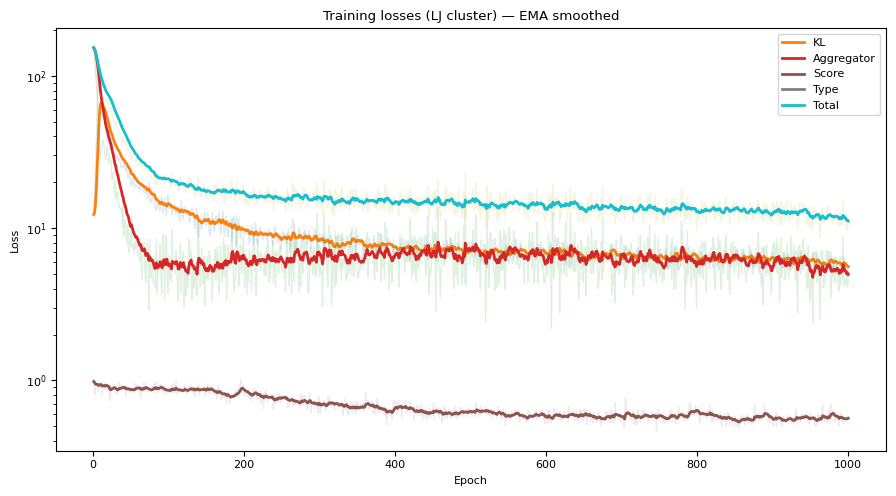

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=5):
    x = np.array(x)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    smoothed = np.convolve(x, kernel, mode='valid')
    # pad the front so the smoothed array lines up with the original x-axis
    pad = np.full(window - 1, smoothed[0])
    return np.concatenate([pad, smoothed])

def ema(x, alpha=0.1):
    """Exponential moving average — smoother than a simple moving average, no lag-padding needed."""
    x = np.array(x)
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

# ---------------- Plot smoothed losses ----------------
plt.figure(figsize=(9, 5))
epochs = np.arange(1, len(hist["total"]) + 1)

for k, lab in [("kl", "KL"), ("aggregator", "Aggregator"),
               ("score", "Score"), ("type", "Type"), ("total", "Total")]:
    raw = np.array(hist[k])
    smooth = ema(raw, alpha=0.15)          # try 0.05-0.2; lower = smoother
    plt.plot(epochs, raw, alpha=0.15, linewidth=1)          # faint raw curve for reference
    plt.plot(epochs, smooth, label=lab, linewidth=2)        # smoothed curve, bold

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training losses (LJ cluster) — EMA smoothed")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/lj_training_losses_smoothed.png", dpi=150)
plt.show()

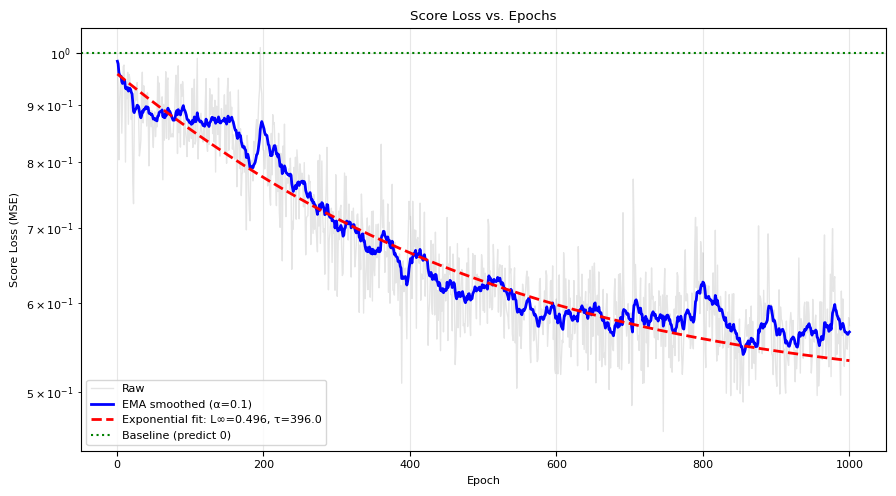

Fitted decay: L0 = 0.959, L_inf = 0.496, tau = 396.0 epochs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define exponential decay function: L(t) = L_inf + (L0 - L_inf) * exp(-t/tau)
def exp_decay(t, L0, L_inf, tau):
    return L_inf + (L0 - L_inf) * np.exp(-t / tau)

# Get the score loss data
score_raw = np.array(hist["score"])
epochs = np.arange(1, len(score_raw) + 1)

# ---- Smoothing (EMA) ----
def ema(x, alpha=0.1):
    x = np.array(x)
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

score_smooth = ema(score_raw, alpha=0.1)

# ---- Exponential fit (using raw data, or smoothed) ----
# Use only the first 80% of epochs to avoid overfitting to final noise
fit_epochs = epochs[:int(0.8 * len(epochs))]
fit_scores = score_raw[:len(fit_epochs)]
try:
    popt, _ = curve_fit(exp_decay, fit_epochs, fit_scores, p0=[1.0, 0.2, 20], maxfev=5000)
    L0_fit, L_inf_fit, tau_fit = popt
    fitted_curve = exp_decay(epochs, *popt)
    fit_label = f'Exponential fit: L∞={L_inf_fit:.3f}, τ={tau_fit:.1f}'
except:
    fitted_curve = None
    fit_label = "Fit failed"

# ---- Plot ----
plt.figure(figsize=(9, 5))
plt.plot(epochs, score_raw, alpha=0.2, linewidth=1, color='gray', label='Raw')
plt.plot(epochs, score_smooth, linewidth=2, color='blue', label='EMA smoothed (α=0.1)')
if fitted_curve is not None:
    plt.plot(epochs, fitted_curve, '--', color='red', linewidth=2, label=fit_label)

# Baseline: constant 1.0 (random guess)
plt.axhline(y=1.0, color='green', linestyle=':', linewidth=1.5, label='Baseline (predict 0)')

plt.xlabel("Epoch")
plt.ylabel("Score Loss (MSE)")
plt.title("Score Loss vs. Epochs")
plt.yscale('log')          # log scale to see early changes
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/score_loss_fit.png", dpi=150)
plt.show()

# Print fitted parameters
if fitted_curve is not None:
    print(f"Fitted decay: L0 = {L0_fit:.3f}, L_inf = {L_inf_fit:.3f}, tau = {tau_fit:.1f} epochs")
else:
    print("Exponential fit did not converge.")

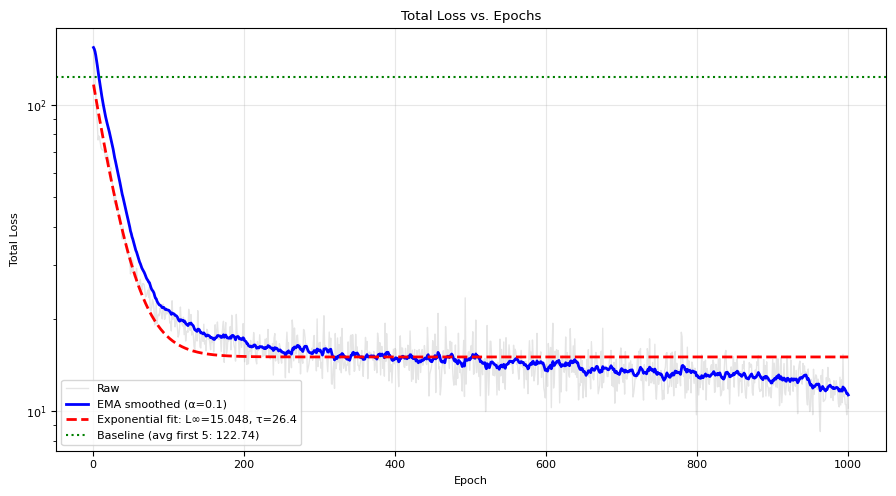

Fitted decay: L0 = 120.045, L_inf = 15.048, tau = 26.4 epochs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def ema(x, alpha=0.1):
    x = np.array(x)
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

# Exponential decay: L(t) = L_inf + (L0 - L_inf) * exp(-t/tau)
def exp_decay(t, L0, L_inf, tau):
    return L_inf + (L0 - L_inf) * np.exp(-t / tau)

total_raw = np.array(hist["total"])
epochs = np.arange(1, len(total_raw) + 1)

# Smooth
total_smooth = ema(total_raw, alpha=0.1)

# Fit (use first 80% of data to avoid overfitting to final noise)
fit_epochs = epochs[:int(0.8 * len(epochs))]
fit_vals = total_raw[:len(fit_epochs)]
try:
    popt, _ = curve_fit(exp_decay, fit_epochs, fit_vals, p0=[max(total_raw), min(total_raw), 20], maxfev=5000)
    L0_fit, L_inf_fit, tau_fit = popt
    fitted_curve = exp_decay(epochs, *popt)
    fit_label = f'Exponential fit: L∞={L_inf_fit:.3f}, τ={tau_fit:.1f}'
except:
    fitted_curve = None
    fit_label = "Fit failed"

# Baseline: initial total loss (or average of first 5 epochs)
baseline = np.mean(total_raw[:5])

# ---- Plot ----
plt.figure(figsize=(9,5))
plt.plot(epochs, total_raw, alpha=0.2, linewidth=1, color='gray', label='Raw')
plt.plot(epochs, total_smooth, linewidth=2, color='blue', label='EMA smoothed (α=0.1)')
if fitted_curve is not None:
    plt.plot(epochs, fitted_curve, '--', color='red', linewidth=2, label=fit_label)

plt.axhline(y=baseline, color='green', linestyle=':', linewidth=1.5, label=f'Baseline (avg first 5: {baseline:.2f})')

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Total Loss vs. Epochs")
plt.yscale('log')          # log scale if values span orders of magnitude
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/total_loss_fit.png", dpi=150)
plt.show()

if fitted_curve is not None:
    print(f"Fitted decay: L0 = {L0_fit:.3f}, L_inf = {L_inf_fit:.3f}, tau = {tau_fit:.1f} epochs")
else:
    print("Exponential fit did not converge.")

In [ ]:
from atomic_recipes.descriptors.ace import ACELayer

os.makedirs(GEN_DIR, exist_ok=True)

# --- FIX 1: Initialize the 'template' object ---
ref_structure = ase_io.read(REF_PATH, format="vasp")

ref_mat = Material(
    direct_positions=torch.tensor(ref_structure.get_scaled_positions()).float(),
    atom_numbers=torch.tensor(ref_structure.numbers),
    lattice_vectors=torch.tensor(ref_structure.get_cell().array).float()
)

mds_ref = MaterialsDataset([ref_mat])
graph_ref = MaterialGraph(mds_ref, cutoff=CUTOFF, use_niggli=True, noise_params=None)
template = graph_ref[0]

if template.lattice_vectors.dim() == 1:
    template.lattice_vectors = template.lattice_vectors.unsqueeze(0)
# -----------------------------------------------

# --- FIX 2: Restored Atomic Number Mapping ---
inv = {int(v): int(k) for k, v in atom_types.items()}
# ---------------------------------------------

lat3 = _niggli_to_reduced(template.lattice_vectors).cpu().numpy()
lat3_t = _niggli_to_reduced(template.lattice_vectors).to(device)

# Pre-compute the inverse lattice matrix for the coordinate transformation
inv_lat3_t = torch.linalg.inv(lat3_t)

sigmas = torch.tensor(np.geomspace(NOISE["sigma_end"], NOISE["sigma_start"], N_SIGMAS),
                      dtype=torch.float32, device=device)
print("[v4i3] sigmas Å (high->low):", sigmas.cpu().numpy().round(4))

def update_edge_attr(g, lat3_t):
    row, col = g.edge_index
    dfrac = g.pos[row] - g.pos[col]; dfrac = dfrac - dfrac.round()
    g.edge_attr = (dfrac @ lat3_t).norm(dim=-1, keepdim=True)
    return g

def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1,0,1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:,None,:] - frac[None,:,:])[:,:,None,:] + shifts[None,None,:,:]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool); zero = (shifts.abs().sum(1) == 0)
    dist[eye[:,:,None] & zero[None,None,:]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()

encoder.eval(); aggregator.eval(); score_dec.eval()
t_gen = time.time(); gen_paths = []; rows = []; torch.manual_seed(0)
sigma_L = sigmas[-1]

for k in range(100):
    g = template.clone().to(device)
    g.pos = torch.rand_like(g.pos)
    g.batch = torch.zeros(g.pos.shape[0], dtype=torch.long, device=device)
    g.num_graphs = 1

    if g.lattice_vectors.dim() == 1:
        g.lattice_vectors = g.lattice_vectors.unsqueeze(0)

    z = torch.randn(1, LATENT, device=device)
    with torch.no_grad():
        for sigma_j in sigmas:
            g.sigma = sigma_j.view(1).to(device)
            alpha_j = (EPSILON * (sigma_j**2) / (sigma_L**2)).item()

            for _ in range(INNER_STEPS):
                g = update_edge_attr(g, lat3_t)

                # --- FIX 3: Explicit Cartesian to Fractional Langevin Step ---
                scores, _ = score_dec(g, z)

                # Model predicts score * sigma, divide to get the true gradient score
                true_scores = scores / sigma_j

                # Calculate the raw Cartesian jump step
                noise = torch.randn_like(g.pos)
                cart_update = alpha_j * true_scores + (2 * alpha_j)**0.5 * noise

                # Multiply by Inverse Lattice to safely map the step into Fractional space!
                frac_update = cart_update @ inv_lat3_t

                g.pos = g.pos + frac_update
                # -------------------------------------------------------------

                g.pos = torch.remainder(g.pos, 1.0)         # safety wrap
    frac = g.pos.cpu().numpy()

    znums = [inv[int(c)] for c in template.x.argmax(1).tolist()]

    atoms = Atoms(numbers=znums, scaled_positions=frac, cell=lat3, pbc=True)
    p = f"{GEN_DIR}/POSCAR_gen_{k:03d}"
    ase_io.write(p, atoms, format="vasp"); gen_paths.append(p)
    md, nn = min_and_nn_distance(frac, lat3)
    rows.append({"structure": k, "min_dist_A": round(md,3), "nn_median_A": round(nn,3),
                 "passes_floor": md >= FLOOR, "nn_in_window": WIN[0] <= nn <= WIN[1]})

print(f"[gen] {len(gen_paths)} structures in {time.time()-t_gen:.1f}s -> {GEN_DIR}")

df = pd.DataFrame(rows)
print(f"\nBond-length filter (floor={FLOOR} A, Si window={WIN[0]}-{WIN[1]} A)")
print(df.to_string(index=False))
print(f"\nPassed overlap floor: {int(df['passes_floor'].sum())}/20  |  "
      f"NN in Si window: {int(df['nn_in_window'].sum())}/20")
df.to_csv("/kaggle/working/v4i3_bondlength_filter.csv", index=False)




[v4i3] sigmas Å (high->low): [1.     0.5995 0.3594 0.2154 0.1292 0.0774 0.0464 0.0278 0.0167 0.01  ]
[gen] 100 structures in 587.1s -> /kaggle/working/Generated_V4i3

Bond-length filter (floor=0.5 A, Si window=0.8-1.4 A)
 structure  min_dist_A  nn_median_A  passes_floor  nn_in_window
         0       1.070        1.072          True          True
         1       1.019        1.035          True          True
         2       1.019        1.071          True          True
         3       1.057        1.111          True          True
         4       0.978        0.990          True          True
         5       1.059        1.108          True          True
         6       1.005        1.030          True          True
         7       1.064        1.088          True          True
         8       1.071        1.089          True          True
         9       1.048        1.076          True          True
        10       1.084        1.103          True          True
        11 

In [ ]:
import time
import numpy as np
import torch
from ase import io as ase_io
from atomic_recipes.descriptors.ace import ACELayer
from atomic_recipes.data.material import Material, MaterialsDataset

# ---------------- Define ACE fingerprint function ----------------
ace = ACELayer(n_limits=[2, 2, 2], l_limits=[2, 2, 2]).to(device)

def ace_fp(atoms_list):
    """Calculates the Atomic Cluster Expansion fingerprint for a list of ASE Atoms."""
    mats = [Material(direct_positions=torch.tensor(a.get_scaled_positions()).float(),
                      atom_numbers=torch.tensor(a.numbers),
                      lattice_vectors=torch.tensor(a.get_cell().array).float())
            for a in atoms_list]
    with torch.no_grad():
        B, _, _ = ace(MaterialsDataset(mats))
    return B.mean(dim=1).cpu().numpy()

# ---------------- Load reference + generated structures ----------------
ref_atoms = ase_io.read(REF_PATH, format="vasp")

gen_atoms, valid_indices = [], []
for i, p in enumerate(gen_paths):
    if os.path.exists(p):
        gen_atoms.append(ase_io.read(p, format="vasp"))
        valid_indices.append(i)
print(f"Loaded {len(valid_indices)}/{len(gen_paths)} generated structures.")
assert gen_atoms, "No valid generated structures found in gen_paths."

# ---------------- ACE fingerprints ----------------
t_ace = time.time()
fps = ace_fp([ref_atoms] + gen_atoms)

fp_ref = fps[0]
fps_gen = fps[1:]

rf_centered = fp_ref - np.mean(fp_ref)
rf_norm_centered = rf_centered / (np.linalg.norm(rf_centered) + 1e-12)

sims_centered = []
for f in fps_gen:
    f_centered = f - np.mean(f)
    f_norm_centered = f_centered / (np.linalg.norm(f_centered) + 1e-12)
    sims_centered.append(float(np.dot(rf_norm_centered, f_norm_centered)))

sims_centered = np.array(sims_centered)
print(f"[ace] finished in {time.time()-t_ace:.2f}s")
print("ACE similarity to reference:", sims_centered.round(3))

Loaded 100/100 generated structures.
[ace] finished in 0.04s
ACE similarity to reference: [1.    1.    1.    0.998 1.    0.999 1.    1.    1.    0.999 1.    1.
 0.989 0.988 0.999 0.999 1.    0.997 0.998 0.999 0.999 0.994 0.995 0.989
 0.999 1.    1.    0.995 0.986 0.993 0.998 0.999 0.999 0.999 0.999 0.998
 0.999 0.999 0.993 0.999 0.998 1.    0.996 0.995 1.    0.992 1.    0.998
 0.999 0.991 0.997 0.999 0.999 0.999 1.    0.999 0.999 0.996 0.998 1.
 1.    1.    0.999 1.    1.    0.998 1.    1.    1.    0.996 0.994 0.997
 1.    0.999 0.995 1.    0.999 0.999 1.    0.999 0.99  0.999 1.    1.
 0.997 0.987 0.995 0.999 1.    0.999 1.    0.999 0.997 0.999 0.999 0.998
 1.    0.998 1.    1.   ]


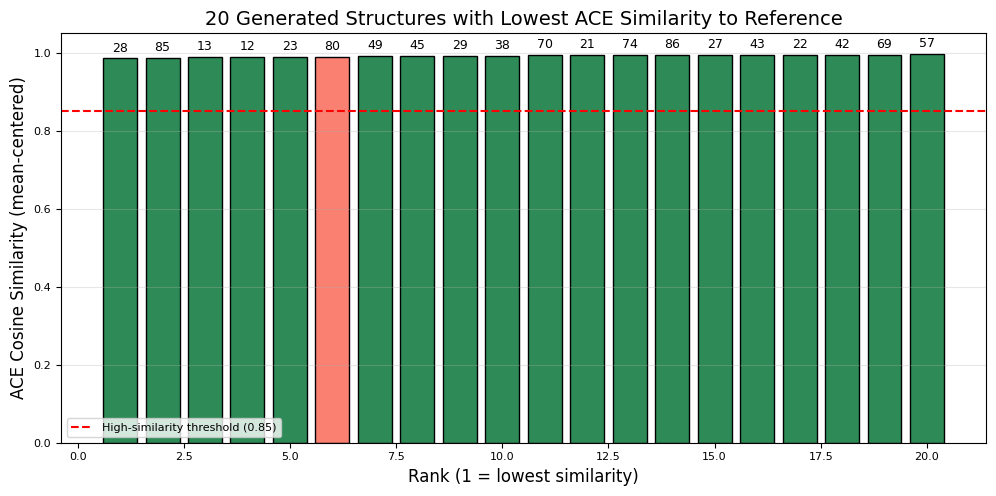

Lowest 20 similarity structures (index, similarity, passes floor>=1.0?):
   28  0.9855  ✅
   85  0.9868  ✅
   13  0.9884  ✅
   12  0.9893  ✅
   23  0.9895  ✅
   80  0.9901  ❌
   49  0.9913  ✅
   45  0.9918  ✅
   29  0.9927  ✅
   38  0.9928  ✅
   70  0.9940  ✅
   21  0.9940  ✅
   74  0.9946  ✅
   86  0.9952  ✅
   27  0.9953  ✅
   43  0.9953  ✅
   22  0.9953  ✅
   42  0.9956  ✅
   69  0.9956  ✅
   57  0.9961  ✅


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sort by similarity (ascending)
sorted_idx = np.argsort(sims_centered)          # indices of structures from lowest to highest similarity
lowest_20_idx = sorted_idx[:20]                 # pick the 20 lowest

# Corresponding similarity values and floor-pass flags
lowest_20_sims = sims_centered[lowest_20_idx]
lowest_20_floor = floor_pass[lowest_20_idx]

# Create a color list: green if passes floor, red otherwise
colors = ['seagreen' if p else 'salmon' for p in lowest_20_floor]

# Sort within the 20 by similarity ascending for a neat bar chart
# (already ascending because we took the first 20 from sorted_idx)
order = np.argsort(lowest_20_sims)  # will be 0..19 since already sorted, but keep for safety
lowest_20_sims_sorted = lowest_20_sims[order]
colors_sorted = [colors[i] for i in order]
# The actual structure indices in the same order
indices_sorted = lowest_20_idx[order]

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(range(1, 21), lowest_20_sims_sorted, color=colors_sorted, edgecolor='black')
plt.xlabel("Rank (1 = lowest similarity)", fontsize=12)
plt.ylabel("ACE Cosine Similarity (mean-centered)", fontsize=12)
plt.title("20 Generated Structures with Lowest ACE Similarity to Reference", fontsize=14)
plt.ylim(0, 1.05)
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label='High-similarity threshold (0.85)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Annotate bars with structure indices
for i, (bar, idx) in enumerate(zip(bars, indices_sorted)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{idx}', ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig("/kaggle/working/lowest_20_similarity.png", dpi=150)
plt.show()

# Print details
print("Lowest 20 similarity structures (index, similarity, passes floor>=1.0?):")
for idx, sim, flag in zip(indices_sorted, lowest_20_sims_sorted, [colors_sorted[i]=='seagreen' for i in range(20)]):
    print(f"  {idx:3d}  {sim:.4f}  {'✅' if flag else '❌'}")

In [ ]:
import os
import shutil
from IPython.display import FileLink, display

# ---------------- Config ----------------
GEN_DIR = "/kaggle/working/Generated_V4i3"   # folder with your raw POSCAR_gen_* files
ZIP_NAME = "generated_raw_structures"        # output zip filename (no extension)

# ---------------- Zip and download ----------------
assert os.path.exists(GEN_DIR), f"GEN_DIR not found: {GEN_DIR}"

n_files = len([f for f in os.listdir(GEN_DIR) if f.startswith("POSCAR_gen_")])
print(f"Found {n_files} raw generated structures in {GEN_DIR}")

shutil.make_archive(f"/kaggle/working/{ZIP_NAME}", 'zip', GEN_DIR)

print("Zipped! Click below to download:")
display(FileLink(f"{ZIP_NAME}.zip"))

Found 100 raw generated structures in /kaggle/working/Generated_V4i3
Zipped! Click below to download:


/kaggle/working/generated_raw_structures.zip

Loaded 100/100 generated structures.
[ace] evaluation finished in 0.04s
Mean-centered ACE similarity to reference: [1.    1.    1.    0.998 1.    0.999 1.    1.    1.    0.999 1.    1.
 0.989 0.988 0.999 0.999 1.    0.997 0.998 0.999 0.999 0.994 0.995 0.989
 0.999 1.    1.    0.995 0.986 0.993 0.998 0.999 0.999 0.999 0.999 0.998
 0.999 0.999 0.993 0.999 0.998 1.    0.996 0.995 1.    0.992 1.    0.998
 0.999 0.991 0.997 0.999 0.999 0.999 1.    0.999 0.999 0.996 0.998 1.
 1.    1.    0.999 1.    1.    0.998 1.    1.    1.    0.996 0.994 0.997
 1.    0.999 0.995 1.    0.999 0.999 1.    0.999 0.99  0.999 1.    1.
 0.997 0.987 0.995 0.999 1.    0.999 1.    0.999 0.997 0.999 0.999 0.998
 1.    0.998 1.    1.   ]
ACE fingerprint RMSE (lower is better):     [0.005  0.0016 0.004  0.0105 0.0044 0.0082 0.0022 0.0025 0.0032 0.0071
 0.0036 0.0033 0.0255 0.0256 0.0068 0.006  0.0024 0.0121 0.0108 0.0062
 0.0086 0.0189 0.017  0.0244 0.0095 0.0035 0.0056 0.0157 0.0282 0.0208
 0.0109 0.0057 0.0089 0.008

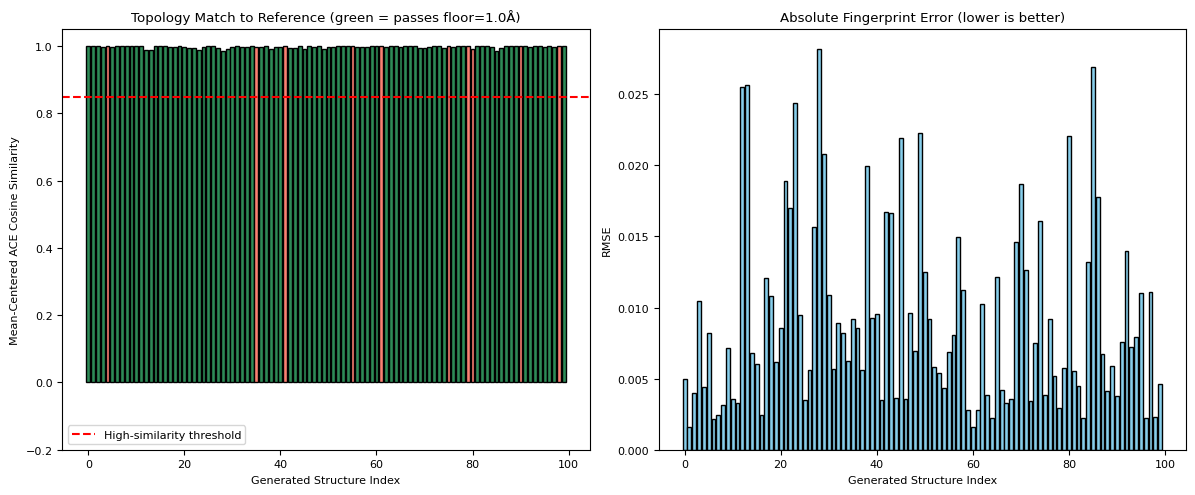

DONE.


In [ ]:
import os, time, itertools
import numpy as np
import torch
import matplotlib.pyplot as plt
from ase import io as ase_io

# ---------------- Config ----------------
FLOOR = 1.0                      # <-- overlap floor threshold you requested (Å)
WIN = (0.8, 1.4)                 # nearest-neighbor "acceptable" window (adjust if needed)

# ---------------- Load reference + generated structures ----------------
ref_atoms = ase_io.read(REF_PATH, format="vasp")

gen_atoms, valid_indices = [], []
for i, p in enumerate(gen_paths):
    if os.path.exists(p):
        gen_atoms.append(ase_io.read(p, format="vasp"))
        valid_indices.append(i)
print(f"Loaded {len(valid_indices)}/{len(gen_paths)} generated structures.")
assert gen_atoms, "No valid generated structures found in gen_paths."

# ---------------- ACE fingerprints ----------------
t_ace = time.time()
fps = ace_fp([ref_atoms] + gen_atoms)

fp_ref = fps[0]
fps_gen = fps[1:]

# Mean-centered reference (topology comparison, robust to overall scale)
rf_centered = fp_ref - np.mean(fp_ref)
rf_norm_centered = rf_centered / (np.linalg.norm(rf_centered) + 1e-12)

# Raw normalized reference (for RMSE)
rf_raw_norm = fp_ref / (np.linalg.norm(fp_ref) + 1e-12)

sims_centered, rmse_scores = [], []
for f in fps_gen:
    f_centered = f - np.mean(f)
    f_norm_centered = f_centered / (np.linalg.norm(f_centered) + 1e-12)
    sims_centered.append(float(np.dot(rf_norm_centered, f_norm_centered)))

    f_raw_norm = f / (np.linalg.norm(f) + 1e-12)
    rmse_scores.append(float(np.sqrt(np.mean((rf_raw_norm - f_raw_norm) ** 2))))

sims_centered = np.array(sims_centered)
rmse_scores = np.array(rmse_scores)

print(f"[ace] evaluation finished in {time.time()-t_ace:.2f}s")
print("Mean-centered ACE similarity to reference:", sims_centered.round(3))
print("ACE fingerprint RMSE (lower is better):    ", rmse_scores.round(4))

# ---------------- Bond-length floor filter (FLOOR=1) ----------------
def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1, 0, 1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:, None, :] - frac[None, :, :])[:, :, None, :] + shifts[None, None, :, :]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool)
    zero = (shifts.abs().sum(1) == 0)
    dist[eye[:, :, None] & zero[None, None, :]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()

floor_pass = []
for atoms in gen_atoms:
    md, nn = min_and_nn_distance(atoms.get_scaled_positions(), atoms.get_cell().array)
    floor_pass.append(md >= FLOOR)
floor_pass = np.array(floor_pass)
print(f"Passed overlap floor (>= {FLOOR} Å): {int(floor_pass.sum())}/{len(gen_atoms)}")

# ---------------- Plot ----------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['seagreen' if p else 'salmon' for p in floor_pass]
ax1.bar(range(len(sims_centered)), sims_centered, color=colors, edgecolor='black')
ax1.set_xlabel("Generated Structure Index")
ax1.set_ylabel("Mean-Centered ACE Cosine Similarity")
ax1.set_title(f"Topology Match to Reference (green = passes floor={FLOOR}Å)")
ax1.set_ylim(-0.2, 1.05)
ax1.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label="High-similarity threshold")
ax1.legend()

ax2.bar(range(len(rmse_scores)), rmse_scores, color='skyblue', edgecolor='black')
ax2.set_xlabel("Generated Structure Index")
ax2.set_ylabel("RMSE")
ax2.set_title("Absolute Fingerprint Error (lower is better)")

plt.tight_layout()
plt.savefig(f"{GEN_DIR}/ace_similarity_floor1.png", dpi=150)
plt.show()

print("DONE.")